Установка всего нужного

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

In [2]:
ru_kr = 14.5
cn_kr = 3.0

Очистка

In [3]:
df = pd.read_csv('./data.csv')

Фильтруем на просроченные

In [4]:
df["mat_date"] = pd.to_datetime(df["mat_date"])

df = df[df["mat_date"] > pd.Timestamp.today()]

df

,id,company_id,isin,name,type,sub_type,currency_id,board_id,ytm,duration,...,issue_size,acruedint,next_coupon,put_option,call_option,mat_date,created_at,updated_at,rating,rating_date
0,004acb1a-418c-4d9a-9f69-09aa3259c887,7707600245,RU000A107UB5,МГКЛ 1P5,fix,to_maturity,SUR,TQCB,25.4028,761,...,500000.0,41.64,2026-05-26,NaN,NaN,2029-02-20,2026-05-06 22:53:56.141247+00,2026-05-09 23:55:16.844999+00,BB,2025-11-21
1,004d79d4-4092-4ead-af36-e9f2179e2436,7707083893,RU000A1045F4,СберИОС493,fix,to_maturity,SUR,TQCB,17.1255,223,...,681514.0,0.00,2026-12-21,NaN,NaN,2026-12-21,2026-05-06 22:53:56.141247+00,2026-05-09 23:55:16.844999+00,NaN,2026-04-10
2,00799f9d-e031-425c-a009-88c205fae267,7707049388,RU000A0JWTN2,Ростел1P1R,fix,to_maturity,SUR,TQCB,12.8652,121,...,15000000.0,31.64,2026-09-10,NaN,NaN,2026-09-10,2026-05-06 22:53:56.141247+00,2026-05-09 23:55:16.844999+00,AAA,2026-04-27
3,007b4395-6b08-4be5-b798-157bc0b6b244,1655096633,RU000A105WZ4,ЛТрейд 1P7,fix,to_maturity,SUR,TQCB,25.5796,289,...,150000.0,7.65,2026-05-20,NaN,NaN,2028-02-09,2026-05-06 22:53:56.141247+00,2026-05-09 23:55:16.844999+00,BBB-,2025-06-05
4,00961ffc-5995-4bc7-8ab8-c78b705f6392,7707083893,RU000A107S77,СберИОС608,fix,to_maturity,SUR,TQCB,11.8005,291,...,982644.0,0.00,2027-02-26,NaN,NaN,2027-02-26,2026-05-06 22:53:56.141247+00,2026-05-09 23:55:16.844999+00,NaN,2026-04-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1135,fed40478-15a1-4d4c-9846-d040eb826b4d,7727290538,RU000A105344,ИАДОМ 1P20,fix,to_maturity,SUR,TQCB,12.6108,1184,...,155407070.0,0.00,2026-06-28,NaN,NaN,2032-06-28,2026-05-06 22:53:56.141247+00,2026-05-09 23:55:16.844999+00,NaN,2025-07-30
1136,fef5f23f-498e-46ce-bbc4-22409892c4c4,7707083893,RU000A106M09,СберИОС579,fix,to_maturity,SUR,TQCB,10.2452,835,...,1642829.0,0.00,2026-06-08,NaN,NaN,2028-08-24,2026-05-06 22:53:56.141247+00,2026-05-09 23:55:16.844999+00,NaN,2026-04-10
1137,ff17006d-d33c-4346-9fd0-b93269730b07,6685151087,RU000A107UU5,Брус 2P02,fix,to_maturity,SUR,TQCB,23.1626,169,...,7500000.0,11.51,2026-05-22,NaN,NaN,2027-03-28,2026-05-06 22:53:56.141247+00,2026-05-09 23:55:16.844999+00,A-,2026-03-30
1138,ff84d81e-c924-4879-8c34-6207e54ba4d3,6141055691,RU000A108FG3,AGROFRGT01,fix,to_maturity,SUR,TQCB,33.9197,204,...,200000.0,54.25,2026-05-14,NaN,NaN,2027-05-13,2026-05-06 22:53:56.141247+00,2026-05-09 23:55:16.844999+00,B,2025-09-15


Выкидываем лишние колонки

In [5]:
df = df.drop(columns=['id', 'rating_date', 'company_id', 'isin', 'type', 'sub_type', 'board_id', 'created_at', 'updated_at', 'lot_size', 'name'])
df = df.dropna(subset=['rating'])

df

,currency_id,ytm,duration,val_today,face_value,price,coupon_period,coupon_percent,issue_size,acruedint,next_coupon,put_option,call_option,mat_date,rating
0,SUR,25.4028,761,1128387.0,1000.0,93.38,91,20.00,500000.0,41.64,2026-05-26,NaN,NaN,2029-02-20,BB
2,SUR,12.8652,121,71463.0,1000.0,102.09,182,19.25,15000000.0,31.64,2026-09-10,NaN,NaN,2026-09-10,AAA
3,SUR,25.5796,289,186163.0,916.8,93.44,30,14.50,150000.0,7.65,2026-05-20,NaN,NaN,2028-02-09,BBB-
5,SUR,19.7946,172,242768.0,1000.0,91.80,365,0.01,395823.0,0.05,2026-10-31,NaN,NaN,2026-10-31,AAA
8,SUR,14.2236,239,422845.0,1000.0,101.40,30,15.50,500000.0,7.22,2026-05-24,NaN,NaN,2027-01-19,A+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1133,SUR,26.5394,879,934750.0,1000.0,102.99,30,25.00,500000.0,16.44,2026-05-17,NaN,NaN,2030-10-23,BB-
1134,SUR,14.3055,85,3392679.0,200.0,98.24,91,5.80,5000000.0,0.19,2026-08-04,NaN,NaN,2026-08-04,AA
1137,SUR,23.1626,169,8336771.0,1000.0,99.99,31,21.00,7500000.0,11.51,2026-05-22,NaN,NaN,2027-03-28,A-
1138,SUR,33.9197,204,551003.0,1000.0,95.73,91,22.50,200000.0,54.25,2026-05-14,NaN,NaN,2027-05-13,B


Добавляем текущую ключевую ставку

In [6]:
df["kr"] = df["currency_id"].map({
    "SUR": ru_kr,
    "CNY": cn_kr
})

Индикаторы на есть ли оферта

In [7]:
df["has_put"] = df["put_option"].notna().astype(int)
df["has_call"] = df["call_option"].notna().astype(int)

df = df.drop(columns=['put_option', 'call_option'])

df

,currency_id,ytm,duration,val_today,face_value,price,coupon_period,coupon_percent,issue_size,acruedint,next_coupon,mat_date,rating,kr,has_put,has_call
0,SUR,25.4028,761,1128387.0,1000.0,93.38,91,20.00,500000.0,41.64,2026-05-26,2029-02-20,BB,14.5,0,0
2,SUR,12.8652,121,71463.0,1000.0,102.09,182,19.25,15000000.0,31.64,2026-09-10,2026-09-10,AAA,14.5,0,0
3,SUR,25.5796,289,186163.0,916.8,93.44,30,14.50,150000.0,7.65,2026-05-20,2028-02-09,BBB-,14.5,0,0
5,SUR,19.7946,172,242768.0,1000.0,91.80,365,0.01,395823.0,0.05,2026-10-31,2026-10-31,AAA,14.5,0,0
8,SUR,14.2236,239,422845.0,1000.0,101.40,30,15.50,500000.0,7.22,2026-05-24,2027-01-19,A+,14.5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1133,SUR,26.5394,879,934750.0,1000.0,102.99,30,25.00,500000.0,16.44,2026-05-17,2030-10-23,BB-,14.5,0,0
1134,SUR,14.3055,85,3392679.0,200.0,98.24,91,5.80,5000000.0,0.19,2026-08-04,2026-08-04,AA,14.5,0,0
1137,SUR,23.1626,169,8336771.0,1000.0,99.99,31,21.00,7500000.0,11.51,2026-05-22,2027-03-28,A-,14.5,0,0
1138,SUR,33.9197,204,551003.0,1000.0,95.73,91,22.50,200000.0,54.25,2026-05-14,2027-05-13,B,14.5,0,0


Заменяем дату погашения на года до погашения

In [8]:
df["ttm"] = (df["mat_date"] - pd.Timestamp.today()).dt.days / 365

df = df.drop(columns=['mat_date'])

df

,currency_id,ytm,duration,val_today,face_value,price,coupon_period,coupon_percent,issue_size,acruedint,next_coupon,rating,kr,has_put,has_call,ttm
0,SUR,25.4028,761,1128387.0,1000.0,93.38,91,20.00,500000.0,41.64,2026-05-26,BB,14.5,0,0,2.756164
2,SUR,12.8652,121,71463.0,1000.0,102.09,182,19.25,15000000.0,31.64,2026-09-10,AAA,14.5,0,0,0.306849
3,SUR,25.5796,289,186163.0,916.8,93.44,30,14.50,150000.0,7.65,2026-05-20,BBB-,14.5,0,0,1.723288
5,SUR,19.7946,172,242768.0,1000.0,91.80,365,0.01,395823.0,0.05,2026-10-31,AAA,14.5,0,0,0.446575
8,SUR,14.2236,239,422845.0,1000.0,101.40,30,15.50,500000.0,7.22,2026-05-24,A+,14.5,0,0,0.665753
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1133,SUR,26.5394,879,934750.0,1000.0,102.99,30,25.00,500000.0,16.44,2026-05-17,BB-,14.5,0,0,4.427397
1134,SUR,14.3055,85,3392679.0,200.0,98.24,91,5.80,5000000.0,0.19,2026-08-04,AA,14.5,0,0,0.205479
1137,SUR,23.1626,169,8336771.0,1000.0,99.99,31,21.00,7500000.0,11.51,2026-05-22,A-,14.5,0,0,0.852055
1138,SUR,33.9197,204,551003.0,1000.0,95.73,91,22.50,200000.0,54.25,2026-05-14,B,14.5,0,0,0.978082


In [9]:
df["next_coupon"] = pd.to_datetime(df["next_coupon"])

df["days_to_coupon"] = (df["next_coupon"] - pd.Timestamp.today()).dt.days
df["coupon_cycle_progress"] = df["days_to_coupon"] / 365
df["coupon_soon"] = (df["days_to_coupon"] <= 30).astype(int)

df = df.drop(columns=['next_coupon'])

In [10]:
df

,currency_id,ytm,duration,val_today,face_value,price,coupon_period,coupon_percent,issue_size,acruedint,rating,kr,has_put,has_call,ttm,days_to_coupon,coupon_cycle_progress,coupon_soon
0,SUR,25.4028,761,1128387.0,1000.0,93.38,91,20.00,500000.0,41.64,BB,14.5,0,0,2.756164,5,0.013699,1
2,SUR,12.8652,121,71463.0,1000.0,102.09,182,19.25,15000000.0,31.64,AAA,14.5,0,0,0.306849,112,0.306849,0
3,SUR,25.5796,289,186163.0,916.8,93.44,30,14.50,150000.0,7.65,BBB-,14.5,0,0,1.723288,-1,-0.002740,1
5,SUR,19.7946,172,242768.0,1000.0,91.80,365,0.01,395823.0,0.05,AAA,14.5,0,0,0.446575,163,0.446575,0
8,SUR,14.2236,239,422845.0,1000.0,101.40,30,15.50,500000.0,7.22,A+,14.5,0,0,0.665753,3,0.008219,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1133,SUR,26.5394,879,934750.0,1000.0,102.99,30,25.00,500000.0,16.44,BB-,14.5,0,0,4.427397,-4,-0.010959,1
1134,SUR,14.3055,85,3392679.0,200.0,98.24,91,5.80,5000000.0,0.19,AA,14.5,0,0,0.205479,75,0.205479,0
1137,SUR,23.1626,169,8336771.0,1000.0,99.99,31,21.00,7500000.0,11.51,A-,14.5,0,0,0.852055,1,0.002740,1
1138,SUR,33.9197,204,551003.0,1000.0,95.73,91,22.50,200000.0,54.25,B,14.5,0,0,0.978082,-7,-0.019178,1


In [11]:
seed = 52

In [12]:
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=seed)

val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=seed)

target = "price"

X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_val = val_df.drop(columns=[target])
y_val = val_df[target]

X_test = test_df.drop(columns=[target])
y_test = test_df[target]

In [13]:
cat_features = [
    "currency_id",
    "rating"
]

cat_features = [c for c in cat_features if c in X_train.columns]

In [14]:
train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)
test_pool = Pool(X_test, y_test, cat_features=cat_features)

In [15]:
model = CatBoostRegressor(
    iterations=5000,
    learning_rate=0.03,
    depth=6,
    loss_function="MAE",
    eval_metric="MAE",
    random_seed=seed,
    verbose=200,
    early_stopping_rounds=200
)

model.fit(
    train_pool,
    eval_set=val_pool,
    use_best_model=True,
)

0:	learn: 5.6702473	test: 4.4542542	best: 4.4542542 (0)	total: 173ms	remaining: 14m 26s
200:	learn: 1.7056794	test: 2.1066963	best: 2.1033396 (199)	total: 5.48s	remaining: 2m 10s
400:	learn: 0.9785817	test: 1.8136829	best: 1.8135537 (399)	total: 10.1s	remaining: 1m 56s
600:	learn: 0.7045035	test: 1.7585218	best: 1.7581720 (599)	total: 14.9s	remaining: 1m 49s
800:	learn: 0.5463483	test: 1.7212200	best: 1.7211239 (799)	total: 19.7s	remaining: 1m 43s
1000:	learn: 0.4531352	test: 1.6887784	best: 1.6883893 (982)	total: 24.9s	remaining: 1m 39s
1200:	learn: 0.3870251	test: 1.6738260	best: 1.6714537 (1158)	total: 29s	remaining: 1m 31s
1400:	learn: 0.3389984	test: 1.6613312	best: 1.6612447 (1399)	total: 32.5s	remaining: 1m 23s
1600:	learn: 0.3020611	test: 1.6488790	best: 1.6488683 (1595)	total: 36.6s	remaining: 1m 17s
1800:	learn: 0.2760189	test: 1.6400531	best: 1.6400531 (1800)	total: 40.4s	remaining: 1m 11s
2000:	learn: 0.2498639	test: 1.6363570	best: 1.6359155 (1984)	total: 44.9s	remaining: 

CatBoostRegressor(depth=6, early_stopping_rounds=200, eval_metric='MAE', iterations=5000, learning_rate=0.03, loss_function='MAE', random_seed=52, verbose=200)

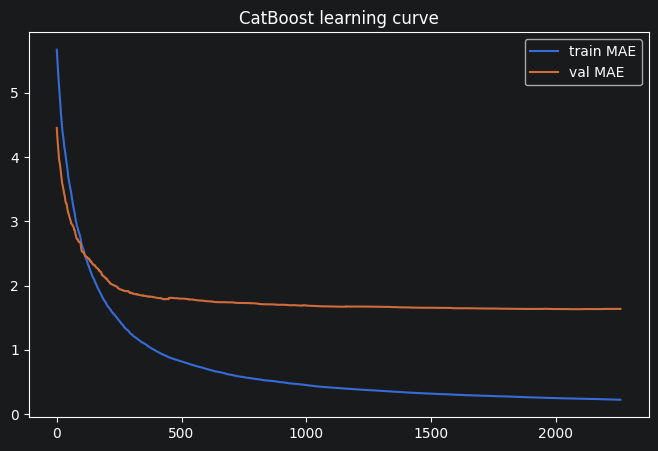

In [16]:
evals = model.get_evals_result()

train_mae = evals["learn"]["MAE"]
val_mae = evals["validation"]["MAE"]

plt.figure(figsize=(8,5))
plt.plot(train_mae, label="train MAE")
plt.plot(val_mae, label="val MAE")
plt.legend()
plt.title("CatBoost learning curve")
plt.show()

In [17]:
pred = model.predict(test_pool)

mae = mean_absolute_error(y_test, pred)
print("TEST MAE:", mae)

TEST MAE: 1.6695151778973825


In [18]:
model.save_model("model")

In [19]:
model.get_all_params()

{'nan_mode': 'Min',
 'eval_metric': 'MAE',
 'combinations_ctr': ['Borders:CtrBorderCount=15:CtrBorderType=Uniform:TargetBorderCount=1:TargetBorderType=MinEntropy:Prior=0/1:Prior=0.5/1:Prior=1/1',
  'Counter:CtrBorderCount=15:CtrBorderType=Uniform:Prior=0/1'],
 'iterations': 5000,
 'sampling_frequency': 'PerTree',
 'fold_permutation_block': 0,
 'leaf_estimation_method': 'Exact',
 'od_pval': 0,
 'random_score_type': 'NormalWithModelSizeDecrease',
 'counter_calc_method': 'SkipTest',
 'grow_policy': 'SymmetricTree',
 'penalties_coefficient': 1,
 'boosting_type': 'Plain',
 'model_shrink_mode': 'Constant',
 'feature_border_type': 'GreedyLogSum',
 'ctr_leaf_count_limit': 18446744073709551615,
 'bayesian_matrix_reg': 0.10000000149011612,
 'one_hot_max_size': 2,
 'eval_fraction': 0,
 'force_unit_auto_pair_weights': False,
 'l2_leaf_reg': 3,
 'random_strength': 1,
 'od_type': 'Iter',
 'rsm': 1,
 'boost_from_average': True,
 'max_ctr_complexity': 4,
 'model_size_reg': 0.5,
 'simple_ctr': ['Border